# 02 — Exploratory Analysis
Explore the cleaned data: output distributions, behaviour over time, and relationships between operating variables. Findings here inform the tier definition and the hypotheses.

In [1]:
#Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('IronProcess_Plant_clean.csv', parse_dates=['date'])

In [3]:
df.dtypes

date                            datetime64[us]
pct_iron_feed                          float64
pct_silica_feed                        float64
starch_flow                            float64
amina_flow                             float64
ore_pulp_flow                          float64
ore_pulp_ph                            float64
ore_pulp_density                       float64
flotation_column_01_air_flow           float64
flotation_column_02_air_flow           float64
flotation_column_03_air_flow           float64
flotation_column_04_air_flow           float64
flotation_column_05_air_flow           float64
flotation_column_06_air_flow           float64
flotation_column_07_air_flow           float64
flotation_column_01_level              float64
flotation_column_02_level              float64
flotation_column_03_level              float64
flotation_column_04_level              float64
flotation_column_05_level              float64
flotation_column_06_level              float64
flotation_col

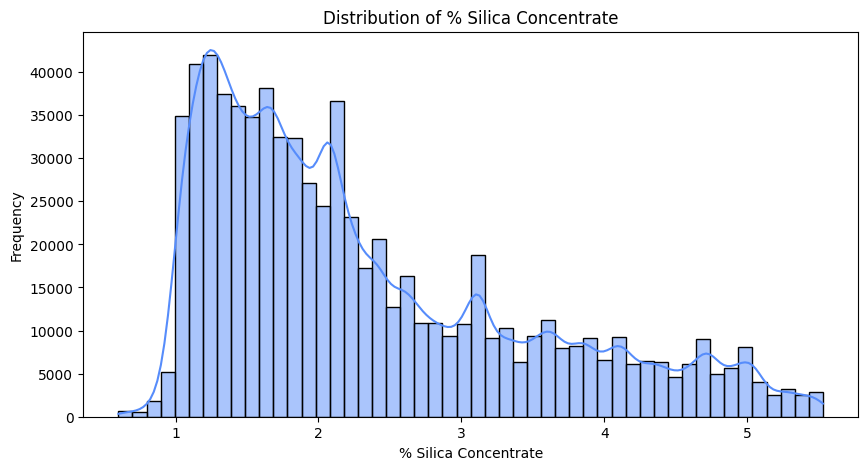

In [4]:
#Histogram to check the distribution of % Silica Concentrate

plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='pct_silica_concentrate', bins=50, kde=True)
plt.title('Distribution of % Silica Concentrate')
plt.xlabel('% Silica Concentrate')
plt.ylabel('Frequency')
plt.show()

**% Silica concentrate** is right-skewed: median ≈ 2.0%, most hours low, with a tail up to ~5.5% (penalty hours).

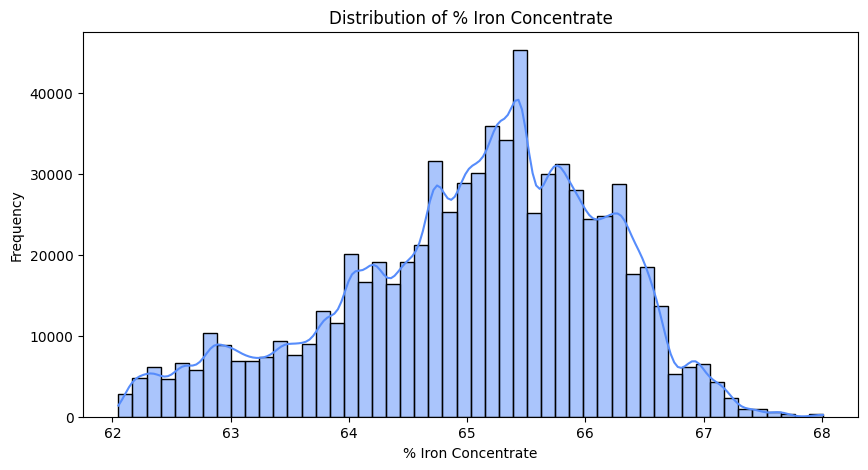

In [5]:
#Histogram to check the distribution of % Iron Concentrate

plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='pct_iron_concentrate', bins=50, kde=True)
plt.title('Distribution of % Iron Concentrate')
plt.xlabel('% Iron Concentrate')
plt.ylabel('Frequency')
plt.show()

**% Iron concentrate** is left-skewed: tightly clustered high (median ≈ 65%), tailing down to ~62%.

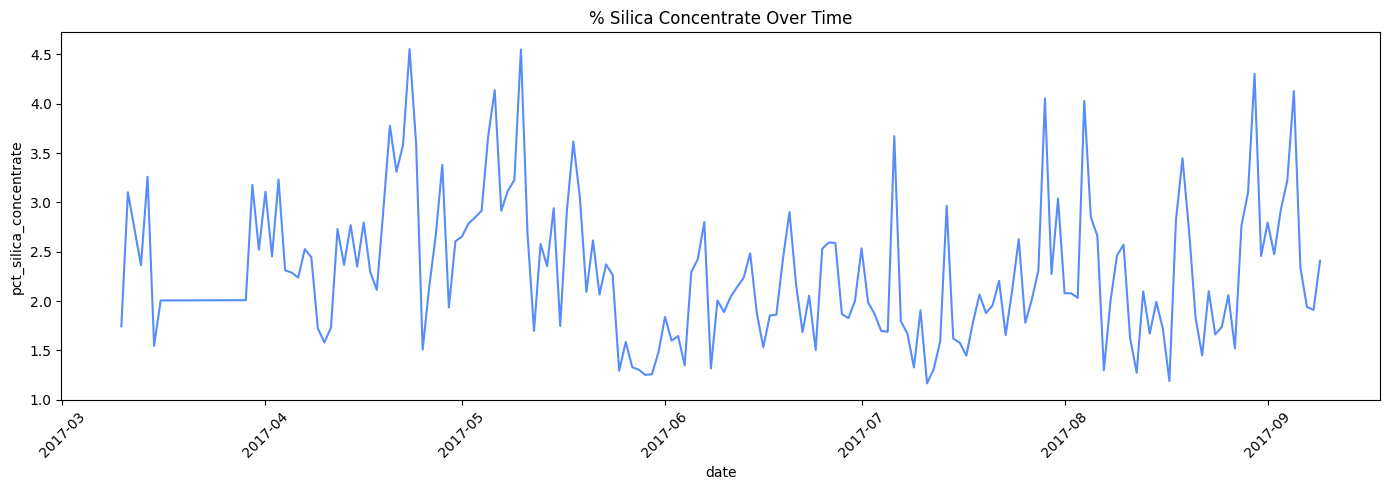

In [6]:
#Over time distribution of % Silica Concentrate

daily = df.set_index('date').resample('D')['pct_silica_concentrate'].mean().reset_index()

plt.figure(figsize=(14, 5))
sns.lineplot(data=daily, x='date', y='pct_silica_concentrate')
plt.title('% Silica Concentrate Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

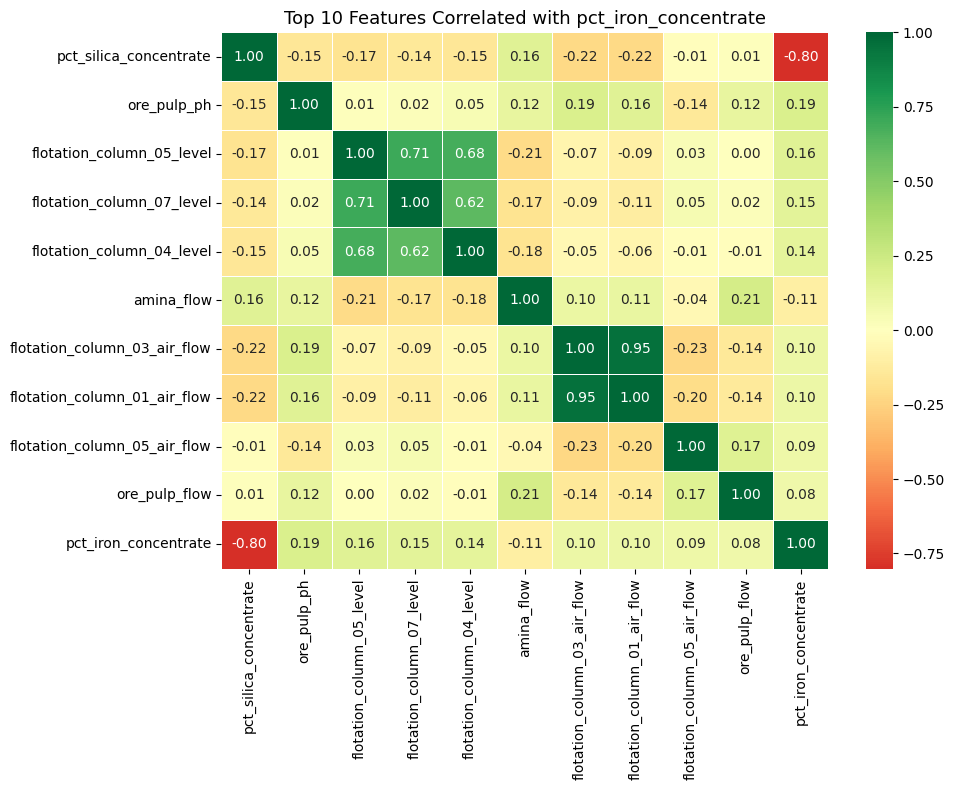

In [13]:
#Correlation heatmap between variables

target_col = "pct_iron_concentrate"
top_n = 10
numeric_df = df.select_dtypes(include='number').dropna(subset=[target_col])

corr = numeric_df.corr()[target_col].drop(target_col)
top = corr.abs().nlargest(top_n).index
corr_matrix = numeric_df[list(top) + [target_col]].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.5)
ax.set_title(f'Top {top_n} Features Correlated with {target_col}', fontsize=13)
plt.tight_layout()
plt.show()

**Key relationship:** iron and silica output are strongly inversely correlated (r ≈ −0.80). This is why quality tiers are defined on silica alone, it implicitly captures most of the iron variation.

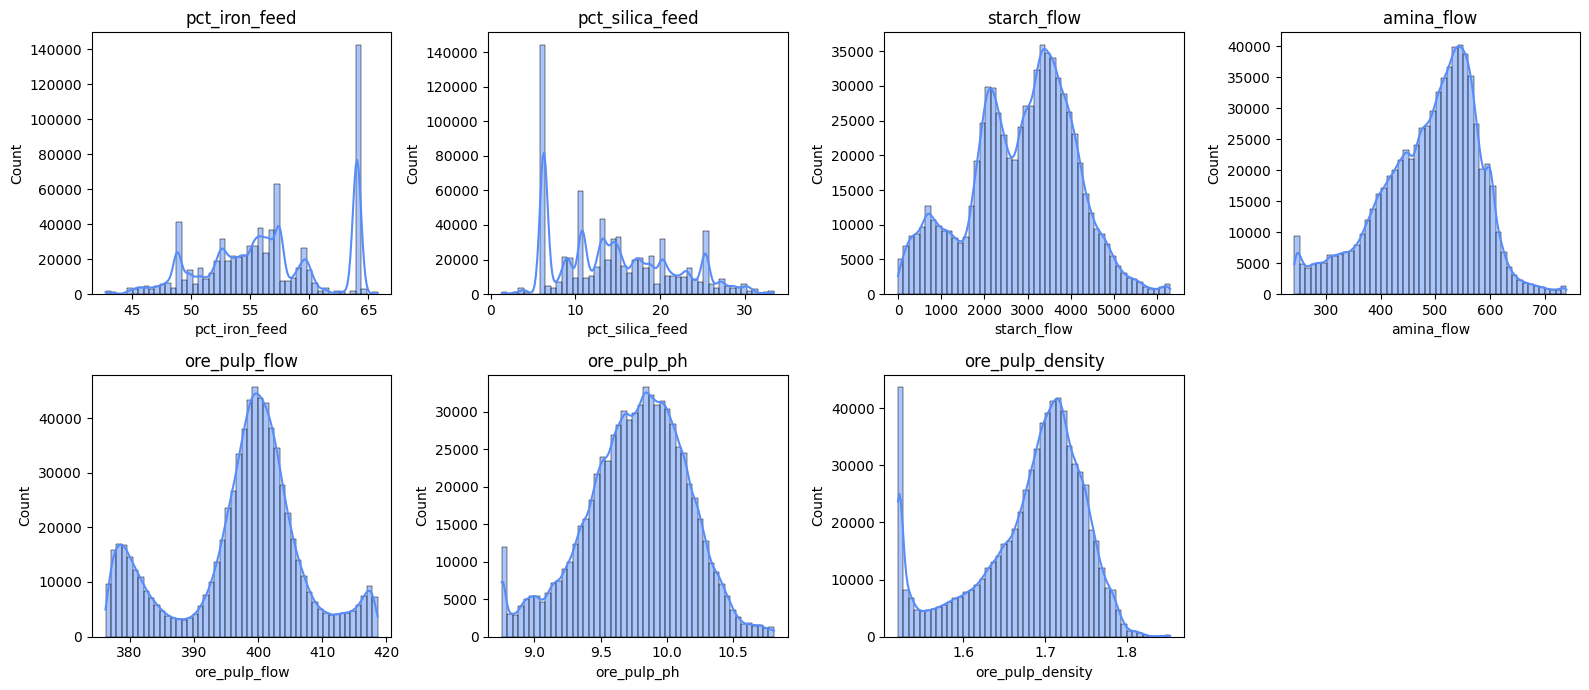

In [7]:
key_inputs = ['pct_iron_feed', 'pct_silica_feed', 'starch_flow', 'amina_flow',
              'ore_pulp_flow', 'ore_pulp_ph', 'ore_pulp_density']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flatten(), key_inputs):
    sns.histplot(df[col], bins=50, kde=True, ax=ax)
    ax.set_title(col)
axes.flatten()[-1].axis('off')
plt.tight_layout()
plt.show()

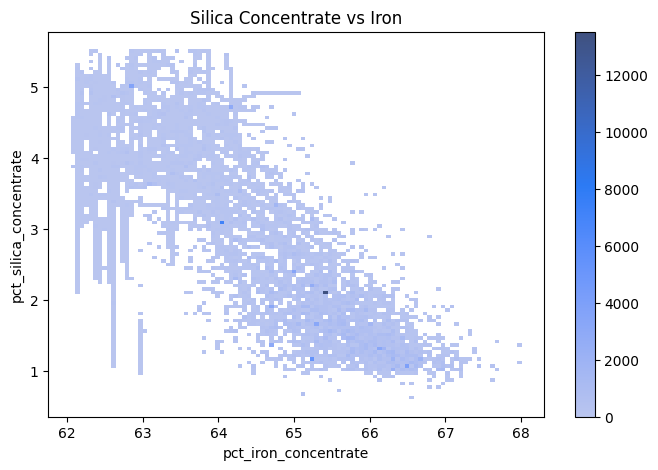

In [21]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='pct_iron_concentrate', y='pct_silica_concentrate', bins=100, cbar=True)
plt.title('Silica Concentrate vs Iron')
plt.show()